# M4 — Daily Total Sales Forecast (AOV × Number of Orders)

Companion to `m1_num_orders_daily.ipynb`. The portfolio-level identity:

    Total Sales(d) = AOV(d) × Number_of_Orders(d)

- **AOV** = total revenue / count(distinct Order Id) per day. Forecast with TimesFM, pre-storm origin (2017-08-31).
- **Number of Orders** = read from `m1_orders_daily.parquet` (already forecast).
- **Total Sales** = the product, with quantiles paired (p10×p10, p50×p50, p90×p90).

**Output:** `forecasts/m4_total_sales_daily.parquet`, schema matches `m1_daily.parquet`
(`product_card_id = 0` is the portfolio sentinel).


In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sns.set_theme(context='notebook', style='whitegrid')

S = pd.read_parquet(ROOT / 'forecasts' / 'm4_total_sales_daily.parquet')
print('shape:', S.shape, ' product_card_id values:', list(S['product_card_id'].unique()))
S.head(3)


shape: (1308, 7)  product_card_id values: [np.int64(0)]


,product_card_id,date,data_type,p10,p50,p90,actual
0,0,2015-01-01,Actual,NaN,NaN,NaN,32806.090690
1,0,2015-01-02,Actual,NaN,NaN,NaN,29818.210575
2,0,2015-01-03,Actual,NaN,NaN,NaN,36348.710648


## 1. Cross-check actuals against the dashboard


In [2]:
S['ym'] = S['date'].values.astype('datetime64[M]')
hist = S[S['data_type']=='Actual']
pred = S[S['data_type']=='Prediction']
monthly_actual = hist.groupby('ym')['actual'].sum().round(0)
print('Last 12 months of actuals (total revenue):')
print(monthly_actual.tail(12))


Last 12 months of actuals (total revenue):
ym
2017-02-01     992535.0
2017-03-01    1048005.0
2017-04-01    1038322.0
2017-05-01    1105485.0
2017-06-01    1032086.0
2017-07-01    1104373.0
2017-08-01    1109337.0
2017-09-01    1143775.0
2017-10-01    1073994.0
2017-11-01     626914.0
2017-12-01     503911.0
2018-01-01     331650.0
Name: actual, dtype: float64


Should match the dashboard exactly (Oct $1.07M, Nov $627K, Dec $504K, Jan $332K).


## 2. Daily series + forecast


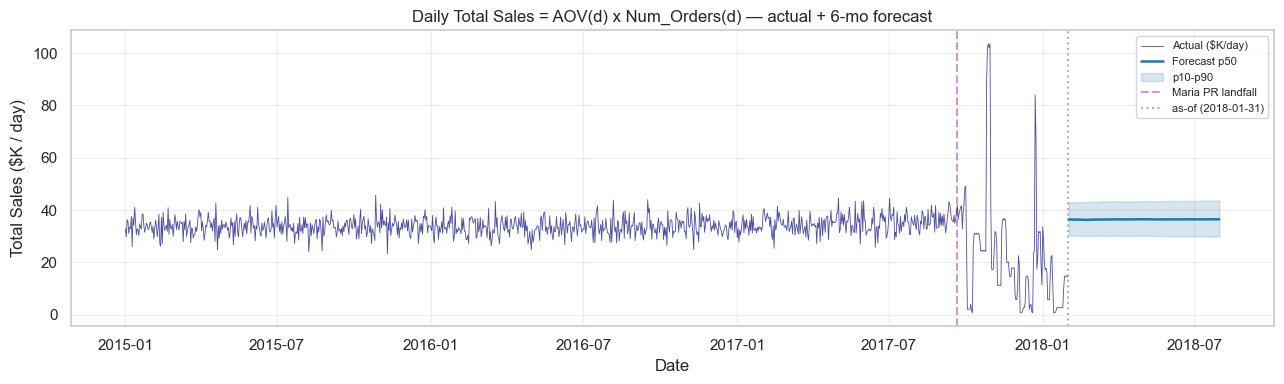

In [3]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(hist['date'], hist['actual']/1e3, color='navy', lw=0.6, alpha=0.7, label='Actual ($K/day)')
ax.plot(pred['date'], pred['p50']/1e3, color='#1f77b4', lw=1.8, label='Forecast p50')
ax.fill_between(pred['date'], pred['p10']/1e3, pred['p90']/1e3,
                 color='#1f77b4', alpha=0.18, label='p10-p90')
ax.axvline(pd.Timestamp('2017-09-20'), color='purple', linestyle='--', alpha=0.4, label='Maria PR landfall')
ax.axvline(pd.Timestamp('2018-01-31'), color='gray', linestyle=':', alpha=0.6, label='as-of (2018-01-31)')
ax.set_title('Daily Total Sales = AOV(d) x Num_Orders(d) — actual + 6-mo forecast')
ax.set_xlabel('Date'); ax.set_ylabel('Total Sales ($K / day)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 3. Monthly aggregation — matches dashboard layout


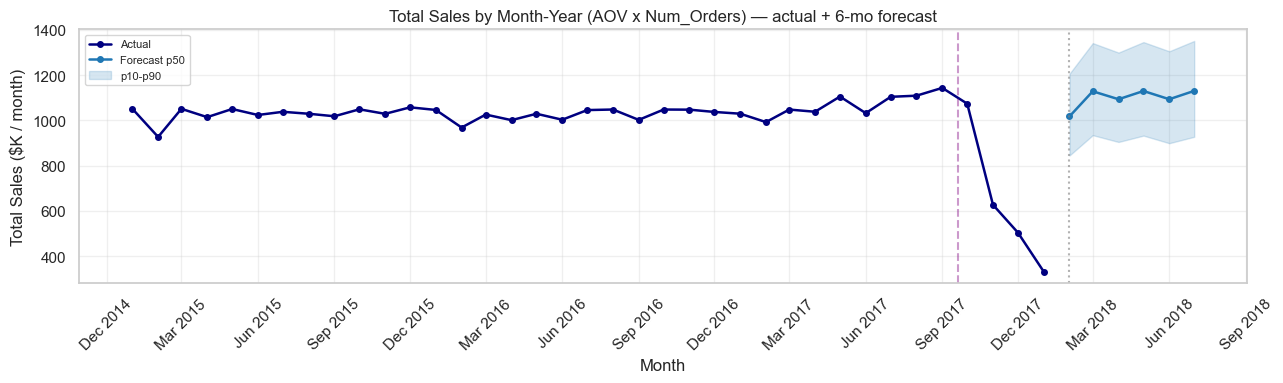

In [4]:
hist_m = hist.groupby('ym')['actual'].sum() / 1e3
p10_m  = pred.groupby('ym')['p10'].sum() / 1e3
p50_m  = pred.groupby('ym')['p50'].sum() / 1e3
p90_m  = pred.groupby('ym')['p90'].sum() / 1e3

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(hist_m.index, hist_m.values, color='navy', lw=1.8, marker='o', ms=4, label='Actual')
ax.plot(p50_m.index, p50_m.values, color='#1f77b4', lw=1.8, marker='o', ms=4, label='Forecast p50')
ax.fill_between(p50_m.index, p10_m.values, p90_m.values, color='#1f77b4', alpha=0.18, label='p10-p90')
ax.axvline(pd.Timestamp('2017-09-20'), color='purple', linestyle='--', alpha=0.4)
ax.axvline(pd.Timestamp('2018-01-31'), color='gray', linestyle=':', alpha=0.6)
ax.set_title('Total Sales by Month-Year (AOV x Num_Orders) — actual + 6-mo forecast')
ax.set_ylabel('Total Sales ($K / month)'); ax.set_xlabel('Month')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend(fontsize=8); ax.grid(alpha=0.3); plt.xticks(rotation=45)
plt.tight_layout(); plt.show()


## 4. Headline forecast


In [5]:
print('6-month total-sales forecast (Feb-Jul 2018):')
print(f"  p10 = ${pred['p10'].sum():>12,.0f}")
print(f"  p50 = ${pred['p50'].sum():>12,.0f}   <- point forecast")
print(f"  p90 = ${pred['p90'].sum():>12,.0f}")
print(f"\n  Daily mean p50:        ${pred['p50'].mean():>10,.0f}")
print(f"  Pre-storm daily mean:  ${hist[hist['date']<=pd.Timestamp('2017-08-31')]['actual'].mean():>10,.0f}")


6-month total-sales forecast (Feb-Jul 2018):
  p10 = $   5,444,090
  p50 = $   6,594,381   <- point forecast
  p90 = $   7,851,395

  Daily mean p50:        $    36,433
  Pre-storm daily mean:  $    33,988


## Identity check

For any day **d**:

    Total Sales(d) = AOV(d) × Number_of_Orders(d)

Both factors come from independent TimesFM models on pre-storm history:
- AOV from per-day total_revenue / distinct order count.
- Orders from per-day count(distinct Order Id).

This decomposition is **cleaner than the per-product M4** (Monte Carlo of qty × elasticity × disaster_drag) because it works at the dashboard's native granularity and has no cohort-mix issues.

**Caveat — quantile band is approximate.** We pair quantiles (p10 × p10) which assumes perfect dependence between AOV and orders. The true joint p10-p90 band is wider (independent uncertainties compound). For a tight uncertainty estimate, sample from the joint distribution.

To re-run:
```bash
python -m src.models.demand.forecast_orders_daily          # produces num_orders forecast
python -m src.models.sales.forecast_total_sales_daily      # produces this
```
